In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
df = pd.read_csv("../data/volume-11kw.csv")
data = df.drop(columns=["time"]).values
data = np.nan_to_num(data)
#超参数
seq_len = 12
batch_size = 32
hidden_size = 64
num_layers = 2
epochs = 40
lr = 0.001
input_size = data.shape[1]

# 标准化 
mean = data.mean(axis=0)
std = data.std(axis=0)
data = (data - mean) / (std + 1e-8)


In [3]:
#构建时序样本
def make_data(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 0])
    return np.array(X), np.array(y)

X, y = make_data(data, seq_len)

In [4]:
# 划分训练/测试集 
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [5]:
# 转为张量 
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [6]:

# 定义数据加载器 
class SensorDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(SensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [7]:
#定义训练函数
def train_model(model, model_name):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loss = []
    test_mse = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for bx, by in train_loader:
            pred = model(bx)
            loss = criterion(pred, by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_loss.append(avg_loss)

        model.eval()
        with torch.no_grad():
            pred_test = model(X_test)
            mse = criterion(pred_test, y_test).item()
        test_mse.append(mse)

        if (epoch+1) % 10 == 0:
            print(f"{model_name} | Epoch {epoch+1:2d} | Loss {avg_loss:.4f} | Test MSE {mse:.4f}")

    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.plot(train_loss)
    plt.title(f"{model_name} 训练损失")
    plt.subplot(122)
    plt.plot(test_mse)
    plt.title(f"{model_name} 测试MSE")
    plt.tight_layout()
    plt.show()
    return train_loss, test_mse

定义模型类搭建网络

In [8]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

RNN | Epoch 10 | Loss 0.0333 | Test MSE 0.3735
RNN | Epoch 20 | Loss 0.0095 | Test MSE 0.3471
RNN | Epoch 30 | Loss 0.0067 | Test MSE 0.3418
RNN | Epoch 40 | Loss 0.0075 | Test MSE 0.3096


C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEO

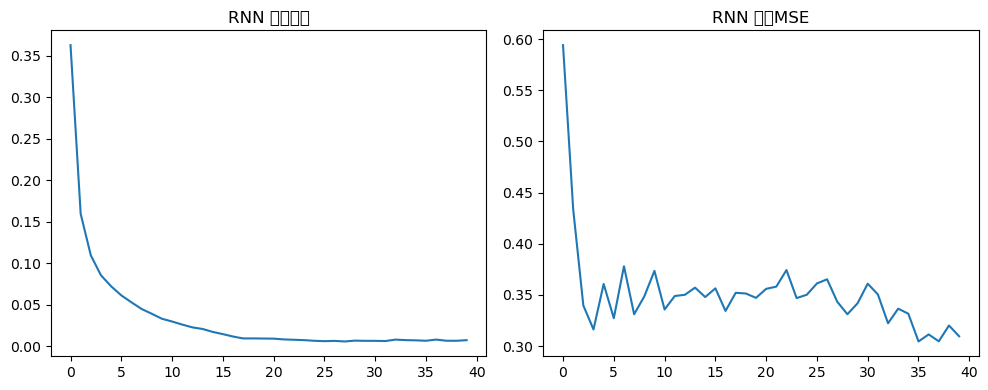

([0.36299327836124173,
  0.15963027359695608,
  0.10964541813922585,
  0.08565066166973989,
  0.07242111579745734,
  0.06149994260674223,
  0.05312801514743665,
  0.04510628613173415,
  0.03935328751392321,
  0.03332339862891293,
  0.030003966037354887,
  0.026311559978564946,
  0.022943982089775692,
  0.021035379354218276,
  0.017492566706288026,
  0.014818626870358483,
  0.01191104156896472,
  0.009613918702314617,
  0.009653094109284496,
  0.009492986927389962,
  0.009378951124060866,
  0.008419365079543733,
  0.008013947514406995,
  0.007580275850267996,
  0.006782549343695608,
  0.0063295417760045975,
  0.006661059734317551,
  0.005973322776257308,
  0.00698623423456052,
  0.006731878314594473,
  0.006708644078446365,
  0.006462325527836834,
  0.008211249402305538,
  0.0075811560120467745,
  0.007326887636402741,
  0.006812418089034634,
  0.008239970506177446,
  0.006856592160589788,
  0.006780739794613435,
  0.007528055920650106],
 [0.5940873026847839,
  0.43379005789756775,
  0.

In [9]:
train_model(RNNModel(), "RNN")

GRU | Epoch 10 | Loss 0.0356 | Test MSE 0.3595
GRU | Epoch 20 | Loss 0.0174 | Test MSE 0.3703
GRU | Epoch 30 | Loss 0.0052 | Test MSE 0.3689
GRU | Epoch 40 | Loss 0.0037 | Test MSE 0.3537


C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEO

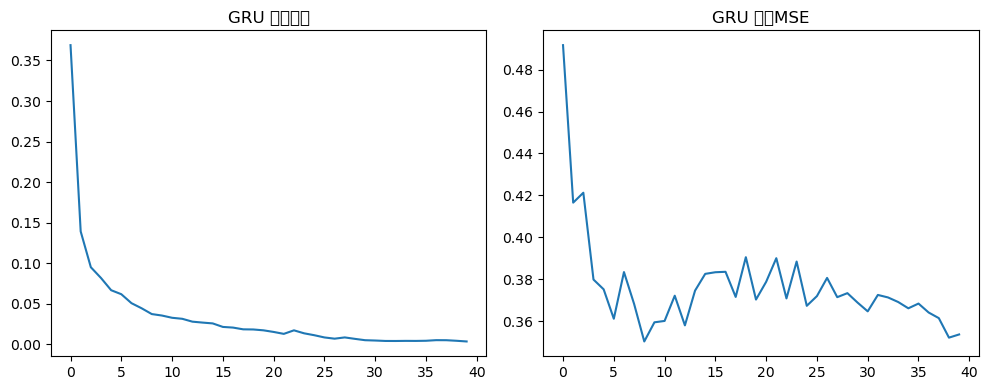

([0.36892016375556996,
  0.13932443080350346,
  0.09518663926955757,
  0.08192495147296049,
  0.06687093230494119,
  0.061935657003057115,
  0.0508950150170184,
  0.0445959262823293,
  0.03746103427859895,
  0.03564953802307264,
  0.03288065248228814,
  0.03163181610166206,
  0.02810671155708372,
  0.026962282460763914,
  0.02594702416142329,
  0.021612055266463974,
  0.020803372687531994,
  0.01864560542269311,
  0.01847278096055219,
  0.01741601204619222,
  0.015432259059348785,
  0.013048741357708607,
  0.017416116405586036,
  0.013731732780814444,
  0.01139745280924125,
  0.008651478224596299,
  0.007127158085328587,
  0.00867916411216106,
  0.006908402779276286,
  0.005249015076957438,
  0.004848737459749394,
  0.0043263788027432535,
  0.004284618361511294,
  0.004417403114088085,
  0.004365901253399773,
  0.004551940388259811,
  0.005301338381245049,
  0.005234597575500471,
  0.004542170412872636,
  0.0036963301512130766],
 [0.4916619658470154,
  0.41654497385025024,
  0.42126557

In [10]:
train_model(GRUModel(), "GRU")

LSTM | Epoch 10 | Loss 0.0384 | Test MSE 0.5402
LSTM | Epoch 20 | Loss 0.0178 | Test MSE 0.5285
LSTM | Epoch 30 | Loss 0.0110 | Test MSE 0.5264
LSTM | Epoch 40 | Loss 0.0061 | Test MSE 0.5216


C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lx\AppData\Local\Temp\ipykernel_20672\3337530852.py:37: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEO

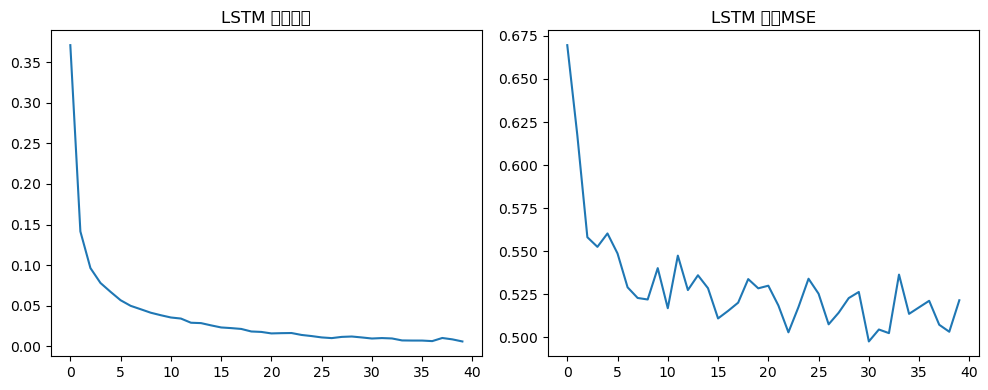

([0.370781058906962,
  0.1414894925071559,
  0.09641706605159908,
  0.07804956309360649,
  0.06717782243744495,
  0.05683272437901672,
  0.049943500993038535,
  0.045745102774112596,
  0.04146478378102867,
  0.03837783278367662,
  0.03559009772682682,
  0.03427960133231288,
  0.02913258794626785,
  0.028666342241228174,
  0.02588867848106754,
  0.02332663674061315,
  0.022520463747066368,
  0.02150108104298284,
  0.018372005620680816,
  0.01781631636202609,
  0.01598402627513086,
  0.0162971168756485,
  0.01647215116546925,
  0.014103716354680444,
  0.012728698735356057,
  0.01105755809566365,
  0.010207445538013216,
  0.01171033669459642,
  0.012179667798699726,
  0.011014363322612068,
  0.009719470571384791,
  0.01026285006963742,
  0.009782063561158443,
  0.007350262374095961,
  0.007200723219184427,
  0.0071824225575722956,
  0.0065137801751699465,
  0.010359318659922808,
  0.008668915166758821,
  0.006082392859469176],
 [0.6696074604988098,
  0.6173884868621826,
  0.55815345048904

In [11]:
train_model(LSTMModel(), "LSTM")